In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model2_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model2_0)
describe(model2_0)

MACs: 5.53 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model2_0.pt
Starting
Epoch 1/60: Train loss = 1.2585, Train accuracy = 0.5438, Test loss = 1.2139, Test accuracy = 0.5583
Epoch 2/60: Train loss = 1.2488, Train accuracy = 0.5665, Test loss = 1.2798, Test accuracy = 0.5683
Epoch 3/60: Train loss = 0.8784, Train accuracy = 0.6894, Test loss = 0.8710, Test accuracy = 0.6911
Epoch 4/60: Train loss = 0.8314, Train accuracy = 0.7081, Test loss = 0.8470, Test accuracy = 0.7062
Epoch 5/60: Train loss = 0.7340, Train accuracy = 0.7441, Test loss = 0.7513, Test accuracy = 0.7415
Epoch 6/60: Train loss = 0.6852, Train accuracy = 0.7623, Test loss = 0.6934, Test accuracy = 0.7561
Epoch 7/60: Train loss = 0.6941, Train accuracy = 0.7591, Test loss = 0.7168, Test accuracy = 0.7533
Epoch 8/60: Train loss = 0.6338, Train accuracy = 0.7774, Test loss = 0.6548, Test accuracy = 0.7771
Epoch 9/60: Train loss = 0.6326, Train accuracy = 0.7807, Test loss = 0.6735, Test accuracy = 0.7666
Epoch 10/60: Train loss = 0.6043

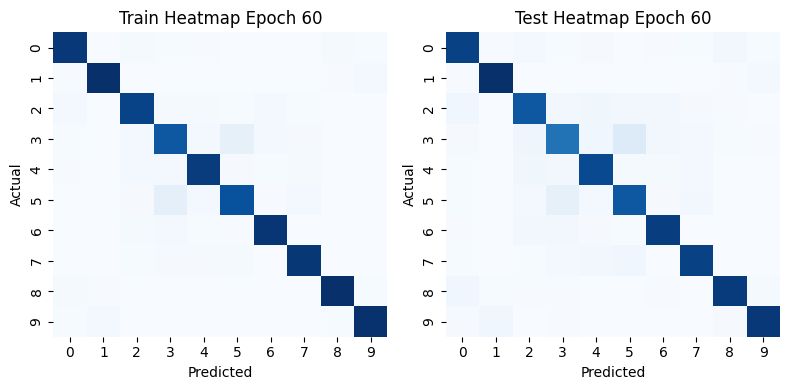

<Figure size 1200x600 with 0 Axes>

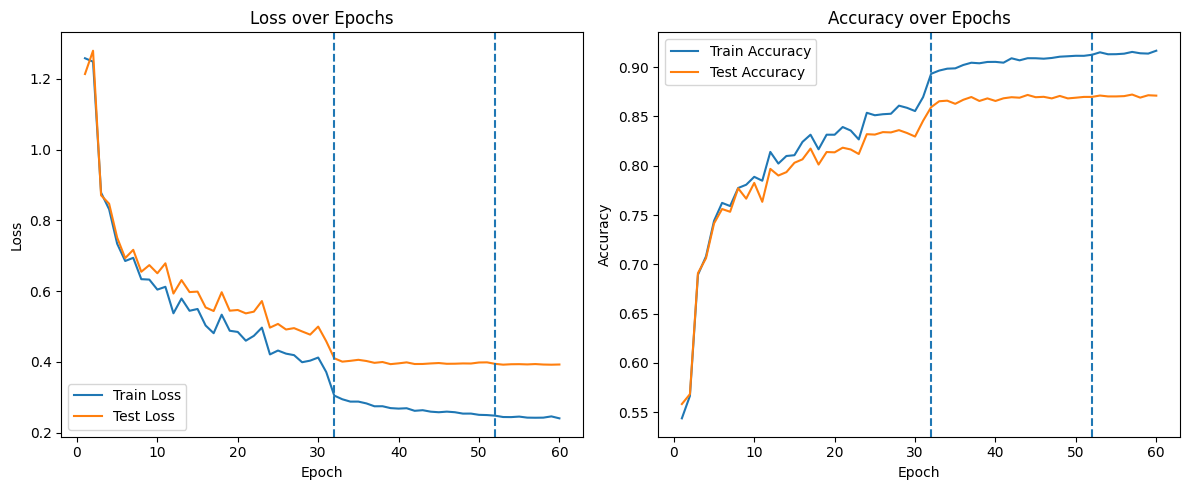

In [6]:
trainf32(model2_0,"model_weights/model2_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model2_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model2_1)
describe(model2_1)

MACs: 5.53 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model2_1.pt
Starting
Epoch 1/60: Train loss = 1.3148, Train accuracy = 0.5642, Test loss = 1.2555, Test accuracy = 0.5819
Epoch 2/60: Train loss = 1.0075, Train accuracy = 0.6483, Test loss = 1.0459, Test accuracy = 0.6405
Epoch 3/60: Train loss = 0.8098, Train accuracy = 0.7184, Test loss = 0.8158, Test accuracy = 0.7172
Epoch 4/60: Train loss = 0.7155, Train accuracy = 0.7480, Test loss = 0.7257, Test accuracy = 0.7503
Epoch 5/60: Train loss = 0.6730, Train accuracy = 0.7651, Test loss = 0.6826, Test accuracy = 0.7678
Epoch 6/60: Train loss = 0.6923, Train accuracy = 0.7619, Test loss = 0.6911, Test accuracy = 0.7642
Epoch 7/60: Train loss = 0.6008, Train accuracy = 0.7920, Test loss = 0.6238, Test accuracy = 0.7867
Epoch 8/60: Train loss = 0.6307, Train accuracy = 0.7795, Test loss = 0.6797, Test accuracy = 0.7719
Epoch 9/60: Train loss = 0.5609, Train accuracy = 0.8026, Test loss = 0.5822, Test accuracy = 0.8029
Epoch 10/60: Train loss = 0.5613

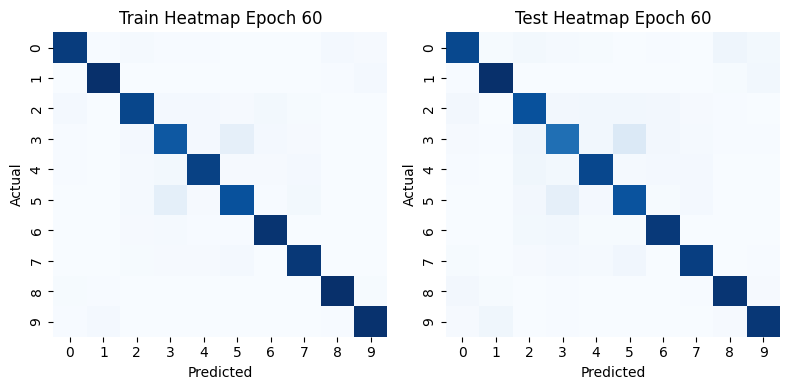

<Figure size 1200x600 with 0 Axes>

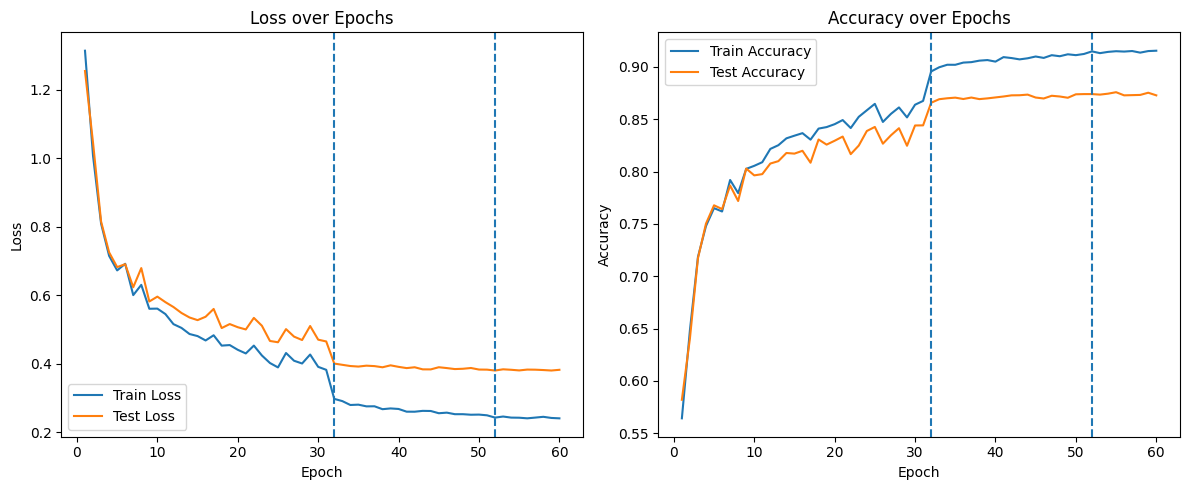

In [8]:
trainf32(model2_1,"model_weights/model2_1.pt",criterion,train_dataset,val_dataset, batch_size=64)